# Classificação de Vinhos - Árvore de Decisão

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
dados = load_wine()

df = pd.DataFrame(dados.data, columns=dados.feature_names)
df["Tipo"] = dados.target

display(df.sample(10))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Tipo
57,13.29,1.97,2.68,16.8,102.0,3.00,3.23,0.31,1.66,6.00,1.07,2.84,1270.0,0
41,13.41,3.84,2.12,18.8,90.0,2.45,2.68,0.27,1.48,4.28,0.91,3.00,1035.0,0
87,11.65,1.67,2.62,26.0,88.0,1.92,1.61,0.40,1.34,2.60,1.36,3.21,562.0,1
114,12.08,1.39,2.50,22.5,84.0,2.56,2.29,0.43,1.04,2.90,0.93,3.19,385.0,1
131,12.88,2.99,2.40,20.0,104.0,1.30,1.22,0.24,0.83,5.40,0.74,1.42,530.0,2
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0,0
13,14.75,1.73,2.39,11.4,91.0,3.10,3.69,0.43,2.81,5.40,1.25,2.73,1150.0,0
18,14.19,1.59,2.48,16.5,108.0,3.30,3.93,0.32,1.86,8.70,1.23,2.82,1680.0,0
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,2
101,12.60,1.34,1.90,18.5,88.0,1.45,1.36,0.29,1.35,2.45,1.04,2.77,562.0,1


In [31]:
dados_preditivos = df[dados.feature_names]

alvos = df["Tipo"]

dados_preditivos_treino, dados_preditivos_teste, alvos_treino, alvos_teste = train_test_split(dados_preditivos, alvos, train_size=0.3, random_state=50)

arvore = DecisionTreeClassifier(max_depth=4, random_state=50)
arvore.fit(dados_preditivos_treino, alvos_treino)

alvos_previsao = arvore.predict(dados_preditivos_teste)

df_previsao = dados_preditivos_teste
df_previsao["Tipo Previsao"] = alvos_previsao
df_previsao["Tipo Gabarito"] = alvos_teste

display(df_previsao)



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Tipo Previsao,Tipo Gabarito
117,12.42,1.61,2.19,22.5,108.0,2.00,2.09,0.34,1.61,2.06,1.06,2.96,345.0,1,1
90,12.08,1.83,2.32,18.5,81.0,1.60,1.50,0.52,1.64,2.40,1.08,2.27,480.0,1,1
80,12.00,0.92,2.00,19.0,86.0,2.42,2.26,0.30,1.43,2.50,1.38,3.12,278.0,1,1
141,13.36,2.56,2.35,20.0,89.0,1.40,0.50,0.37,0.64,5.60,0.70,2.47,780.0,2,2
143,13.62,4.95,2.35,20.0,92.0,2.00,0.80,0.47,1.02,4.40,0.91,2.05,550.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,12.04,4.30,2.38,22.0,80.0,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580.0,1,1
52,13.82,1.75,2.42,14.0,111.0,3.88,3.74,0.32,1.87,7.05,1.01,3.26,1190.0,0,0
29,14.02,1.68,2.21,16.0,96.0,2.65,2.33,0.26,1.98,4.70,1.04,3.59,1035.0,0,0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,0


'Precisão: 94.40%'

array([[42,  2,  0],
       [ 3, 44,  2],
       [ 0,  0, 32]])

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        44
           1       0.96      0.90      0.93        49
           2       0.94      1.00      0.97        32

    accuracy                           0.94       125
   macro avg       0.94      0.95      0.95       125
weighted avg       0.94      0.94      0.94       125



,Dado,Importância
0,alcohol,0.000000
1,malic_acid,0.000000
2,ash,0.000000
3,alcalinity_of_ash,0.000000
4,magnesium,0.000000
5,total_phenols,0.000000
6,flavanoids,0.416303
7,nonflavanoid_phenols,0.000000
8,proanthocyanins,0.000000
9,color_intensity,0.402169


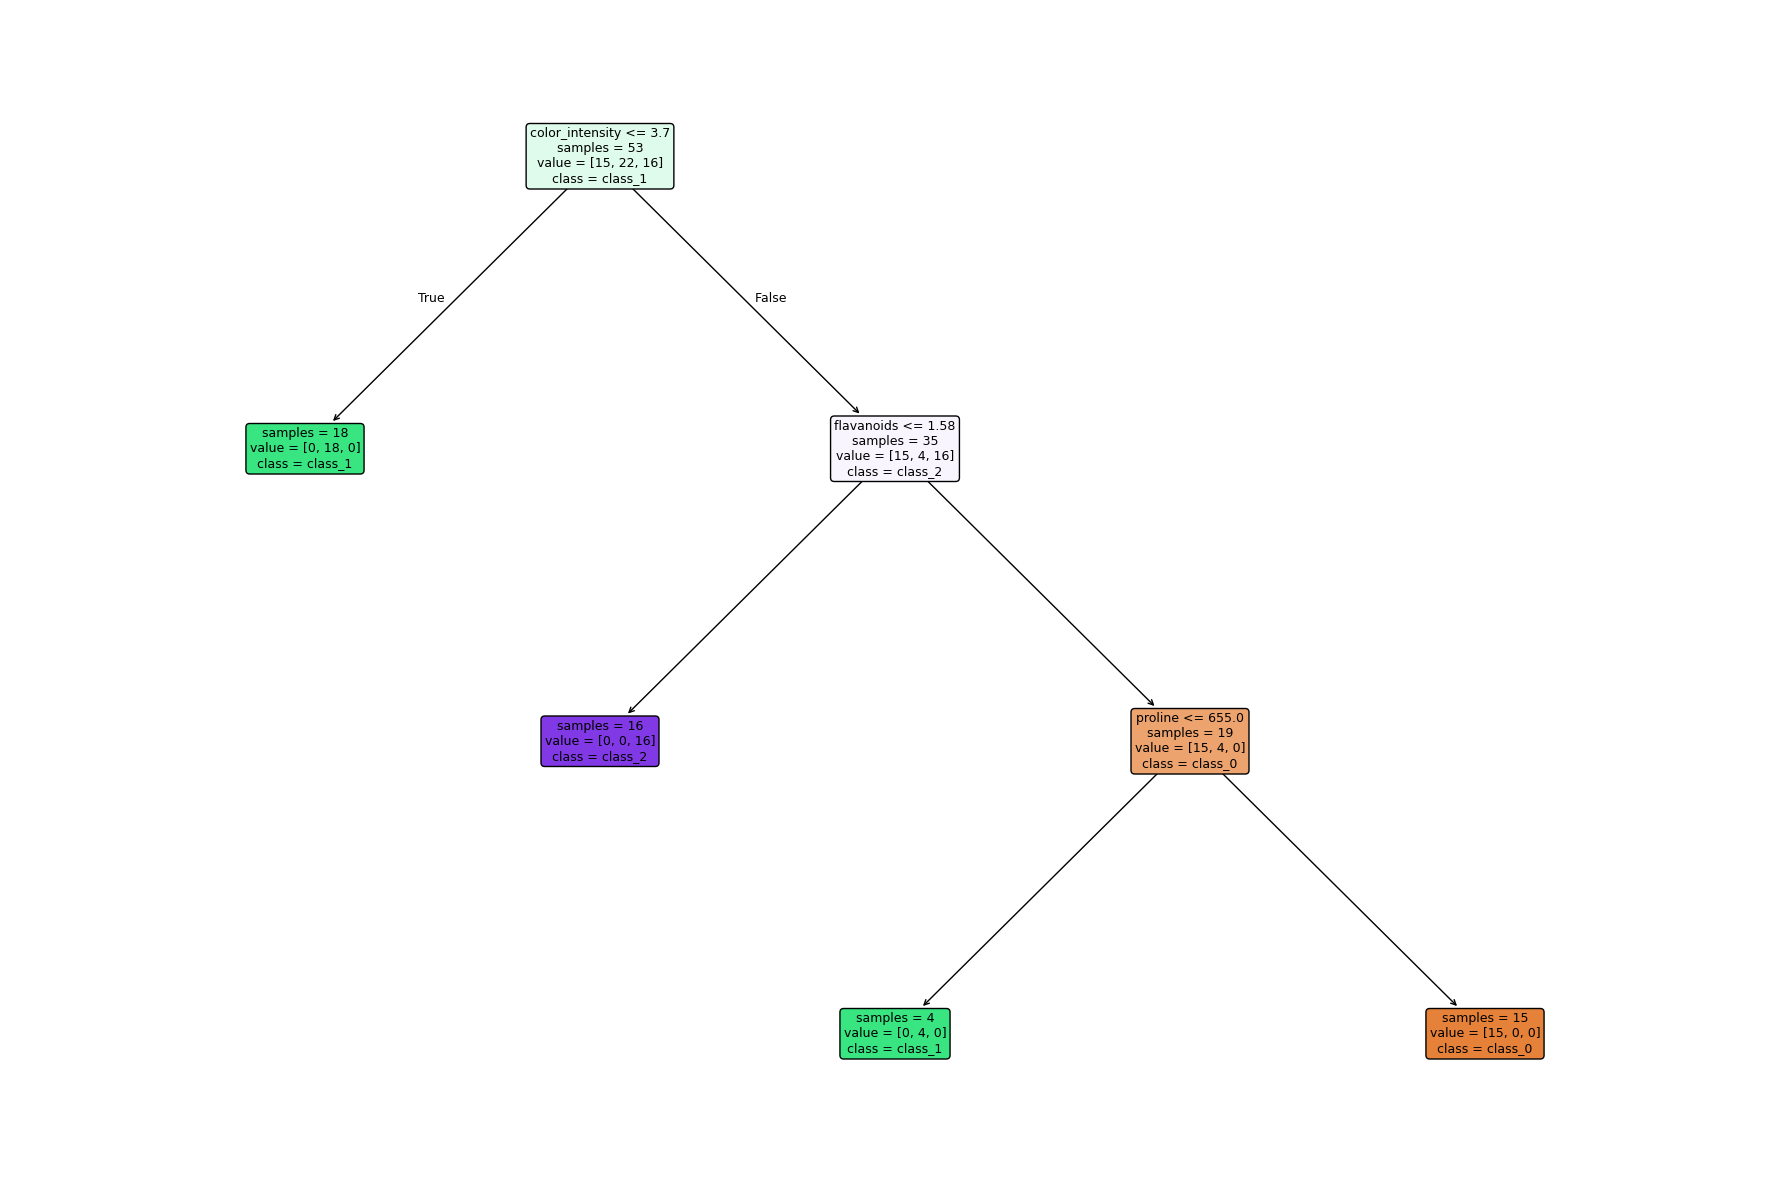

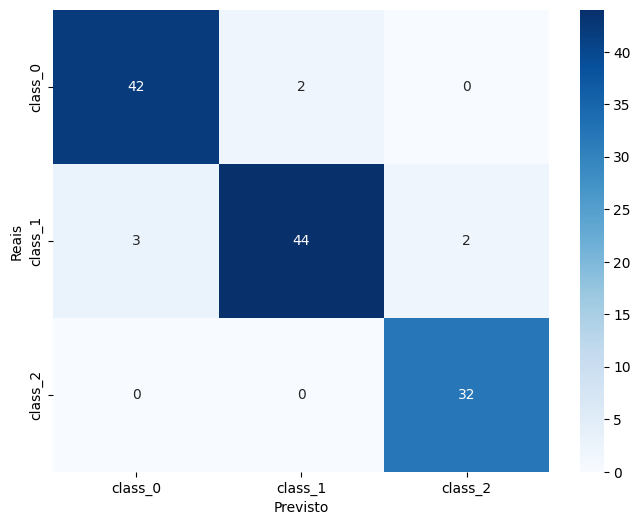

In [32]:
precisao = accuracy_score(alvos_teste, alvos_previsao)

display(f"Precisão: {precisao*100:.2f}%")

matrix_da_confusao = confusion_matrix(alvos_teste, alvos_previsao)
display(matrix_da_confusao)

relatorio_classificacao = classification_report(alvos_teste, alvos_previsao)

print(relatorio_classificacao)

importancias = pd.DataFrame({
    "Dado": dados.feature_names,
    "Importância": arvore.feature_importances_
}
)
display(importancias)

plt.figure(figsize=(18,12))
plot_tree(
    arvore,
    feature_names= dados.feature_names,
    class_names= dados.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(
    matrix_da_confusao, annot=True, fmt="d", cmap="Blues",
    xticklabels=dados.target_names,
    yticklabels=dados.target_names
)
plt.xlabel("Previsto")
plt.ylabel("Reais")
plt.show()